In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import random
import matplotlib.cm as cm
import networkx as nx

import gurobipy as gp
from gurobipy import GRB

## Funzioni Utili

### 2.1 Disegniamo la scacchiera

Questa funzione ha uno scopo puramente didattico: non è necessario che la capiate fino in fondo, ma se siete curiosi di mettere alla prova le vostre skill informatiche potete dare un'occhiata! 😉

In [2]:
# Define the function to plot the solution chessboard
def plot_chessboard(erased_cells = None, domino_cells = None):
    
    # Define the size of the chessboard (8x8)
    chessboard_size = 8
    
    # Define the colors for the chessboard
    vanilla = "#f3e5ab"
    brown = "#a52a2a"
    
    domino_colors = [
    '#FFB347',  # Darker Pastel Orange
    '#FF6961',  # Light Coral
    '#FFD700',  # Mustard Yellow
    '#6A5ACD',  # Slate Blue
    '#C39BD3',  # Medium Lavender
    '#77DD77',  # Pastel Green
    '#FF6347',  # Tomato (Darker Red)
    '#FF8C00',  # Dark Orange
    '#66CDAA',  # Medium Aquamarine
    '#87CEEB',  # Sky Blue
    '#9ACD32',  # Yellow-Green
    '#DDA0DD',  # Plum (Darker)
    '#E9967A',  # Darker Light Salmon
    '#CD5C5C',  # Indian Red (Darker Pastel Red)
    '#BA55D3',
    '#FFA07A',  # Light Salmon
    '#40E0D0',  # Turquoise
    '#F08080',  # Light Coral 2
    '#98FB98',  # Pale Green
    '#AFEEEE',  # Pale Turquoise
    '#DB7093',  # Pale Violet Red
    '#B0E0E6',  # Powder Blue
    '#F4A460',  # Sandy Brown
    '#DAA520',  # Goldenrod
    '#90EE90',  # Light Green
    '#BDB76B',  # Dark Khaki
    '#FFB6C1',  # Light Pink
    '#00CED1',  # Dark Turquoise
    '#FF69B4',  # Hot Pink
    '#EEE8AA',  # Pale Goldenrod
    '#20B2AA',  # Light Sea Green
    '#E0FFFF'   # Light Cyan
    ]   # Medium Orchid
    
    
    cells_map = {'a': 7, 'b': 6, 'c': 5,
                 'd': 4, 'e': 3, 'f': 2,
                 'g': 1, 'h': 0}
    
    # Create the chessboard pattern
    chessboard = np.zeros((chessboard_size, chessboard_size))
    
    # Fill the chessboard with colors
    for i in range(chessboard_size):
        for j in range(chessboard_size):
            if (i + j) % 2 == 0:
                chessboard[i, j] = 1  # Vanilla color for even sum indices
            else:
                chessboard[i, j] = 0  # Brown color for odd sum indices
    
    # Plot the chessboard
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(chessboard, cmap=plt.get_cmap("copper", 2), origin='upper')
    
    
    # Set ticks and labels
    ax.set_xticks(np.arange(chessboard_size))
    ax.set_yticks(np.arange(chessboard_size))

    # Label the x and y axis like a chessboard
    ax.set_xticklabels(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h'][::-1])
    ax.set_yticklabels(np.arange(1, chessboard_size + 1))  # Reverse for chessboard numbering
    
    
    ax.set_xticks(np.arange(chessboard_size + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(chessboard_size + 1) - 0.5, minor=True)

    ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
    
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=True, labelleft=True)

    

    # If there are erased cells, plot them as forbidden cells
    if erased_cells:
        for cell in erased_cells:
            x, y = cell
            rect = plt.Rectangle((cells_map[x] - 0.5, y - 1 - 0.5), 1, 1, facecolor="red", edgecolor="red")
            ax.add_patch(rect)
            circle = plt.Circle((cells_map[x], y - 1), 0.35, color='white', fill=False, linewidth=3)
            ax.add_patch(circle)
            # Draw the diagonal line
            ax.plot([cells_map[x] -0.5 + 0.8, cells_map[x] -0.5 + 0.2], [y -1.5 + 0.2, y -1.5 + 0.8],  color='white', linewidth=3)
            
            
    if domino_cells:
        for idx, domino in enumerate(domino_cells):
            # domino_color = random.choice(domino_colors)
            domino_color = domino_colors[idx % len(domino_colors)]
            
            (x1, y1), (x2, y2) = domino
            
            # Draw the domino rectangle spanning two cells
            
            rect1 = plt.Rectangle((cells_map[x1] - 0.5, y1 - 1 - 0.5), 1, 1, facecolor = domino_color, edgecolor=None)
            rect2 = plt.Rectangle((cells_map[x2] - 0.5, y2 - 1 - 0.5), 1, 1, facecolor = domino_color, edgecolor=None)
            ax.add_patch(rect1)
            ax.add_patch(rect2)

            # Generate random numbers for domino
            num1, num2 = random.randint(1, 6), random.randint(1, 6)

            # Function to plot the pips (white circles) representing the domino numbers
            def draw_pips(x, y, num):
                pip_positions = {
                    1: [(0.5, 0.5)],
                    2: [(0.25, 0.75), (0.75, 0.25)],
                    3: [(0.25, 0.75), (0.5, 0.5), (0.75, 0.25)],
                    4: [(0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)],
                    5: [(0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75), (0.5, 0.5)],
                    6: [(0.25, 0.25), (0.75, 0.25), (0.25, 0.5), (0.75, 0.5), (0.25, 0.75), (0.75, 0.75)],
                }
                for (dx, dy) in pip_positions[num]:
                    ax.add_patch(plt.Circle((y + dy, x + dx), 0.1, color='white'))

            # Draw pips for both halves of the domino
            draw_pips(y1 - 1 - 0.5, cells_map[x1] - 0.5, num1)
            draw_pips(y2 - 1 - 0.5, cells_map[x2] - 0.5, num2)
    
    
    
    plt.show()


    
# Test the function with some erased cells

# plot_chessboard(
#                 erased_cells=[('g', 6), ('e', 7), ('a', 2)],
#                 domino_cells = [(('d',2), ('c',2)), (('c',3), ('c',4)), (('e',5), ('d',5))]
#                 )

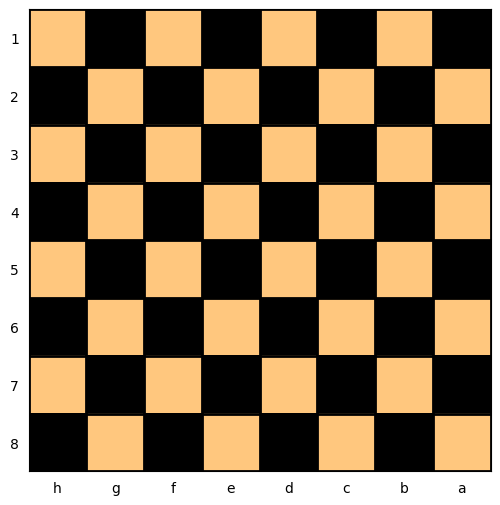

In [3]:
plot_chessboard()

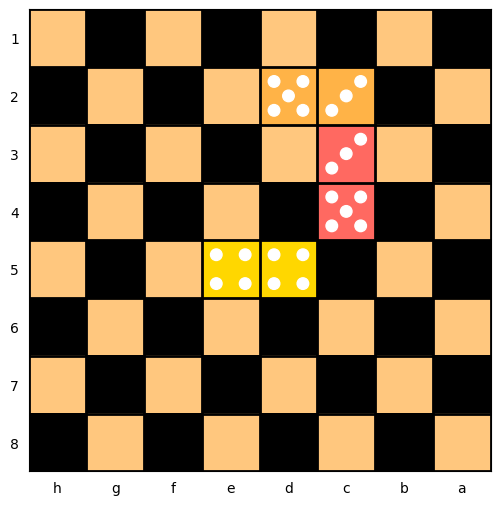

In [4]:
plot_chessboard(
                
                domino_cells = [(('d',2), ('c',2)), (('c',3), ('c',4)), (('e',5), ('d',5))]
                )

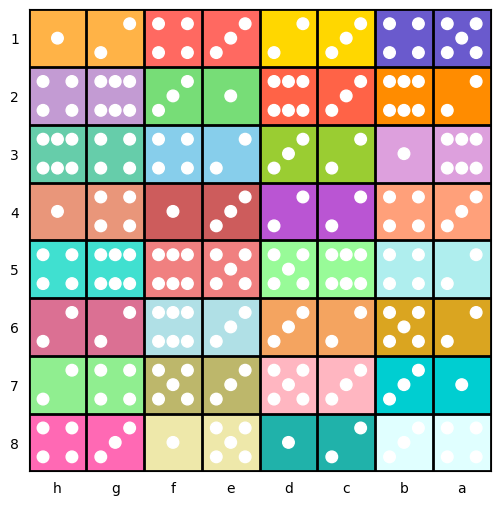

In [5]:
plot_chessboard(
                domino_cells = [
                    (('h',1), ('g',1)), 
                    (('f',1), ('e',1)), 
                    (('d',1), ('c',1)), 
                    (('b',1), ('a',1)),
                    
                    (('h',2), ('g',2)), 
                    (('f',2), ('e',2)), 
                    (('d',2), ('c',2)), 
                    (('b',2), ('a',2)),

                    (('h',3), ('g',3)), 
                    (('f',3), ('e',3)), 
                    (('d',3), ('c',3)), 
                    (('b',3), ('a',3)),

                    (('h',4), ('g',4)),
                    (('f',4), ('e',4)), 
                    (('d',4), ('c',4)), 
                    (('b',4), ('a',4)),

                    (('h',5), ('g',5)), 
                    (('f',5), ('e',5)), 
                    (('d',5), ('c',5)), 
                    (('b',5), ('a',5)),

                    (('h',6), ('g',6)), 
                    (('f',6), ('e',6)), 
                    (('d',6), ('c',6)), 
                    (('b',6), ('a',6)),

                    (('h',7), ('g',7)),
                    (('f',7), ('e',7)), 
                    (('d',7), ('c',7)), 
                    (('b',7), ('a',7)),

                    (('h',8), ('g',8)), 
                    (('f',8), ('e',8)), 
                    (('d',8), ('c',8)), 
                    (('b',8), ('a',8)),
                    
                    ]
                )

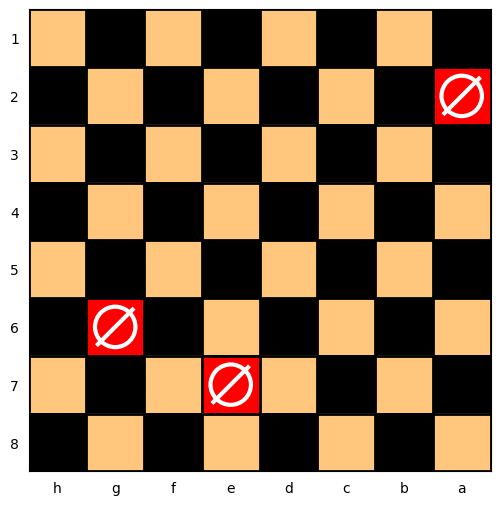

In [6]:
plot_chessboard(
                erased_cells=[('g', 6), ('e', 7), ('a', 2)],
                # domino_cells = [(('d',2), ('c',2)), (('c',3), ('c',4)), (('e',5), ('d',5))]
                )

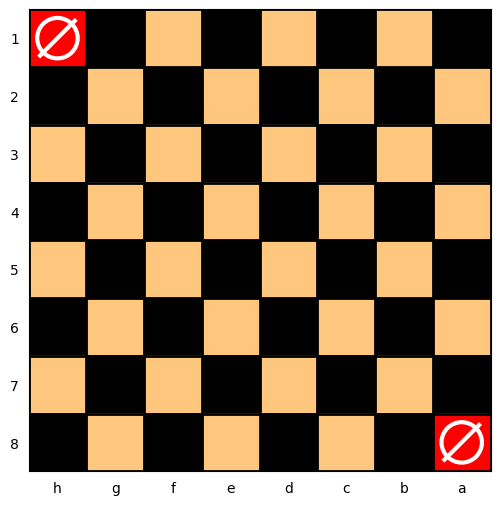

In [7]:
plot_chessboard(
                erased_cells=[('h', 1), ('a', 8)],
                )

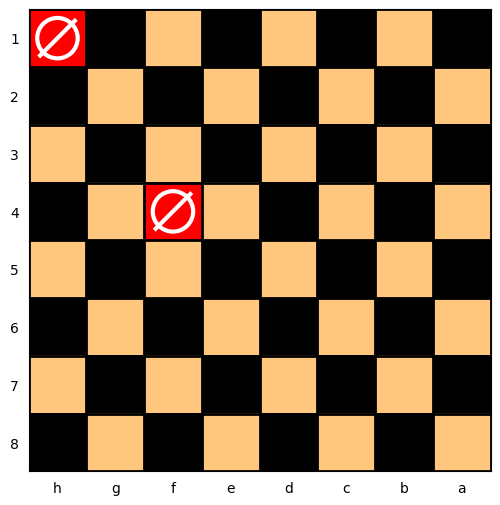

In [8]:
plot_chessboard(
                erased_cells=[('h', 1), ('f', 4)],
                )

### 2.2 Costruiamo il grafo associato al problema

<ins>Il problema delle regine può essere ricondotto a un problema su grafo</ins>. In particolare, vorremmo trovare un sottoinsieme delle caselle in cui posizionare le regine, tale che le regine posizionate non siano *in conflitto* tra loro. 

Vi ricorda qualcosa? 🤔 \
Sembra un problema di **massimo insieme stabile su grafo**! 😯

Possiamo modellare i **conflitti come archi** che collegano caselle che si trovano sulla stessa riga, sulla stessa colonna, che hanno lo stess colore o che appartengono allo stesso *intorno*.

La funzione ``plot_graph`` costruisce e mostra il grafo associato al problema delle regine.

In [9]:
N = 8
nodes = [i for i in range(N*N)]


In [10]:
def plot_graph(board, N, nodes_to_remove = []):
    
    # Build the graph corresponding to the chessboard
    G = nx.Graph()

    G.add_nodes_from([
        (
            node, 
            {
                'color': 'black' if ((idx // 8 + idx % 8) % 2 == 0) else "#a52a2a"
            }
        )
        for idx, node in enumerate(board)
    ])

    # # We also need to add an edge between each pair of cells belonging to the same "neighborhood"...
    for i in range(N*N):
        if i % N != N-1:
            G.add_edge(i, i+1)
        if i + N < N*N:
            G.add_edge(i, i+N)


    ##Non va bene questa formula senza doppi indici
    for node_r in nodes_to_remove:
        G.remove_node(node_r)
    
    
    # # Plot the graph in a very nice way (with correct colors and nodes position)
    node_colors = [G.nodes[node]['color'] for node in G.nodes()]
    # pos = {node : (node // N, node % N) for node in G.nodes} 
    pos = {node : (node % N, N - (node // N)) for node in G.nodes} 

    nx.draw(G, pos = pos, node_color=node_colors)
    
    return G

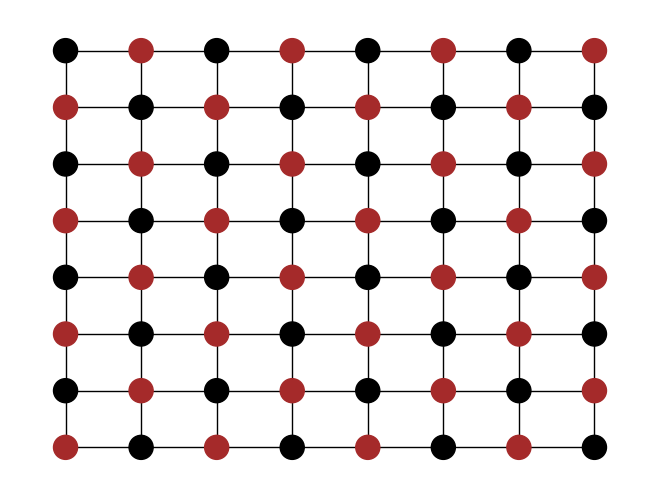

In [11]:
G = plot_graph(nodes, N)

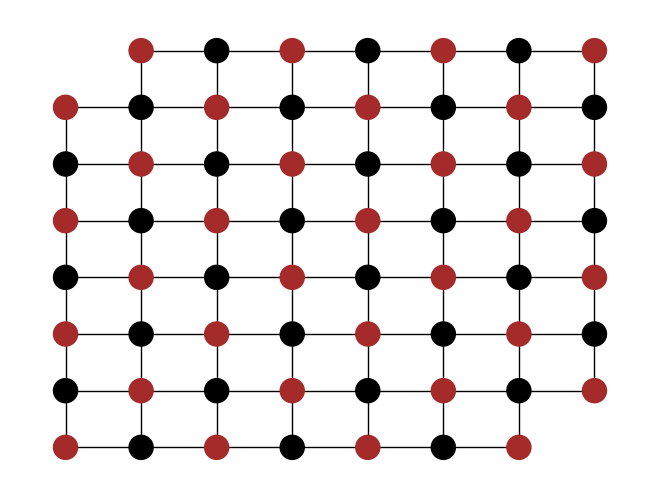

In [12]:
nodes_to_remove = [0, 63]
G = plot_graph(nodes, N, nodes_to_remove)

## 3. Risolvere il problema

### 3.1 Un primo approccio: modello MIP e solver commerciale

Ad alcuni sarà già venuto in mente di risolvere il problema scrivendone la **formulazione naturale** e lasciandolo risolvere da un solutore commerciale.

Di seguito, per i più curiosi, una possibile formulazione del problema che non richiede la costruzione di un grafo.

Introduciamo i seguenti insiemi:

$\mathcal{V} = \{1, \dots, n\} \quad \text{Insieme delle caselle della scacchiera}$ \
$E = \{1, \dots, m\} \quad \text{Insieme degli archi che collegano le caselle della scacchiera}$
<!--  -->


Per comodità, introduciamo anche la seguente funzione:

Infine, le variabili decisionali del problema:

$$ 
x_{uv} =
\begin{cases} 
1 \quad \quad \text{se ho posizionato una tessera sui nodi } (u,v) \quad \forall \, (u, v) \in E \\
0 \quad \quad \text{altrimenti}
\end{cases}
$$


Una possibile formulazione del problema è dunque la seguente (notate bene che la funzione obiettivo è arbitraria, visto che si tratta di un problema di ammissibilità e dunque non necessita di funzione obiettivo):


&nbsp;

$$
\begin{align}
&&   \min_{\boldsymbol{x} \, \in \, \{0, 1\}^{m n}} \quad \sum_{u,v \in E} x_{uv} \\
&&   \sum_{u,v \in\delta(v)} \quad x_{uv}  \,  & = 1,     &  \forall \, v \in V, \\
\end{align}
$$

&nbsp;


La funzione ``solve_PL02_chessboard`` è una possibile implementazione di quanto appena descritto.

In [13]:
# Take a look if yo are interested in MILP modeling and commercial solvers!

def solve_PL0chessboard(G):
    
    
    model = gp.Model('chessboard_domino')


    # x_{i,j} = 1 if a tessera is put inside cell i,j
    x = model.addVars(list(G.edges()), vtype = GRB.BINARY, name = "x")  


    # Objective function (in theory, we could also use a dummy o.f.)
    model.setObjective(sum(x[u, v] for (u, v) in G.edges()), GRB.MINIMIZE)

    # What about the constraints?
    for v in G.nodes():
        elems = []
        for u in G.neighbors(v):
            if (v,u) in x:
                elems.append((v,u))
            if (u,v) in x:
                elems.append((u,v))
        
        if len(elems) > 0:
            model.addConstr(gp.quicksum(x[u,v] for (u, v) in elems) == 1)

    model.write('chessboard_domino.lp')
    
    # Let's solve it, GUROBI BRUTE FORCE!
    model.optimize()
    
            
    return model, x

In [14]:
model, x = solve_PL0chessboard(G)

solution = []

if model.status == GRB.OPTIMAL:
    print("Optimal solution found!")
    for (u,v) in x:
        if x[u,v].X == 1:
            solution.append((u,v))

Set parameter Username
Set parameter LicenseID to value 2782407
Academic license - for non-commercial use only - expires 2027-02-24
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 9800X3D 8-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 62 rows, 108 columns and 216 nonzeros (Min)
Model fingerprint: 0x2077294c
Model has 108 linear objective coefficients
Variable types: 0 continuous, 108 integer (108 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Presolve removed 12 rows and 18 columns
Presolve time: 0.00s

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 0

Model is infeasible
Best objective -, best bound -, gap -


## Plot Solution

In [15]:
def convert_edge_to_cell(input_nodes):
    cells = []
    mapping_rows = {0: 'h', 1: 'g', 2: 'f', 3: 'e', 4: 'd', 5: 'c', 6: 'b', 7: 'a'}

    for sol in input_nodes:
        u, v = sol[0], sol[1]

        u_i, u_j = (u // N) + 1, mapping_rows[u % N]
        v_i, v_j = (v // N) + 1, mapping_rows[v % N]
        
        if ((v_j, v_i), (u_j, u_i)) not in cells:
            cells.append(
                (
                    (u_j, u_i), (v_j, v_i)
                )
            )

    return cells

def convert_node_to_cell(input_nodes):
    cells = []
    mapping_rows = {0: 'h', 1: 'g', 2: 'f', 3: 'e', 4: 'd', 5: 'c', 6: 'b', 7: 'a'}

    for node in input_nodes:

        u_i, u_j = (node // N) + 1, mapping_rows[node % N]
        
        cells.append((u_j, u_i))

    return cells


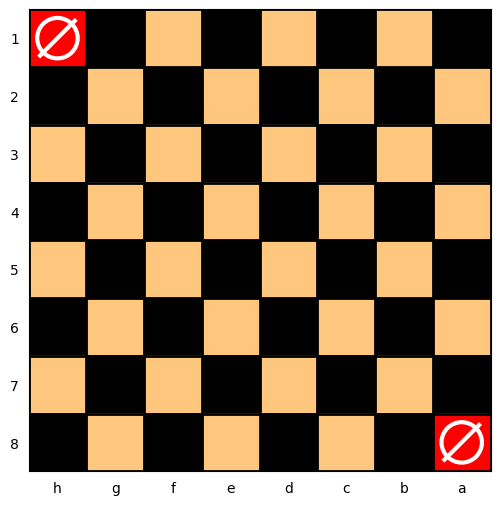

In [16]:
cells = convert_edge_to_cell(solution)
cells_to_erase = convert_node_to_cell(nodes_to_remove)

plot_chessboard(
                erased_cells=cells_to_erase,
                domino_cells = cells
                )

## Example

In [33]:
# PER RIMUOVERE LE CELLE DELLA SCACCHIERA

# nodes_to_remove = [0, 63]
# nodes_to_remove = [0, 1]
nodes_to_remove = [40, 41, 49, 57]

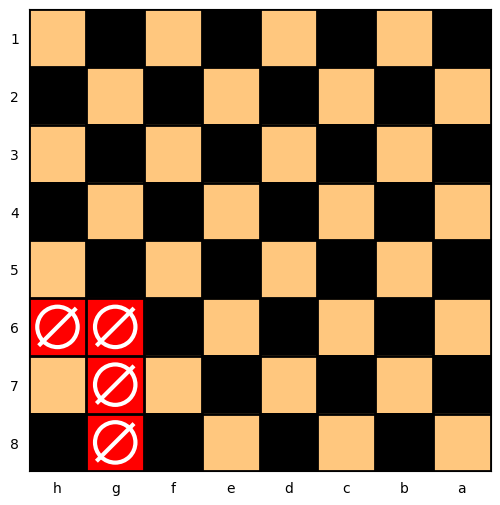

In [34]:
cells_to_erase = convert_node_to_cell(nodes_to_remove)

plot_chessboard(
                erased_cells=cells_to_erase
                )

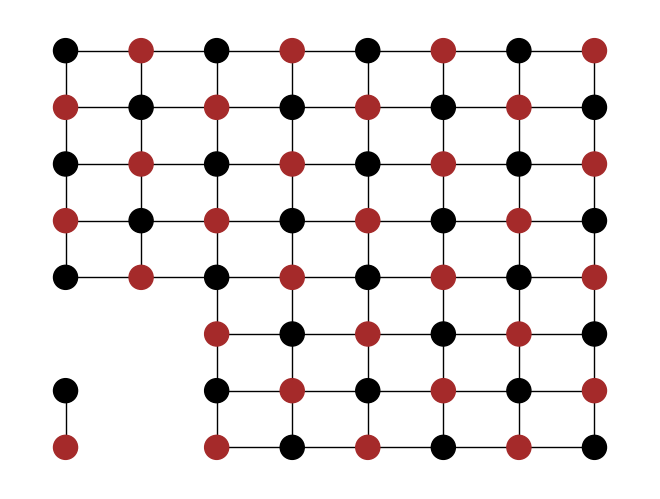

In [35]:

G = plot_graph(nodes, N, nodes_to_remove)

In [36]:
model, x = solve_PL0chessboard(G)

solution = []

if model.status == GRB.OPTIMAL:
    print("Optimal solution found!")
    for (u,v) in x:
        if x[u,v].X == 1:
            solution.append((u,v))

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 9800X3D 8-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 60 rows, 101 columns and 202 nonzeros (Min)
Model fingerprint: 0x082129d0
Model has 101 linear objective coefficients
Variable types: 0 continuous, 101 integer (101 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 30.0000000
Presolve removed 12 rows and 16 columns
Presolve time: 0.00s
Presolved: 48 rows, 85 columns, 170 nonzeros
Variable types: 0 continuous, 85 integer (85 binary)

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 8 (of 8 available processors)

Solution count 1: 30 

Optimal solution found (tolerance 1.00e-04)

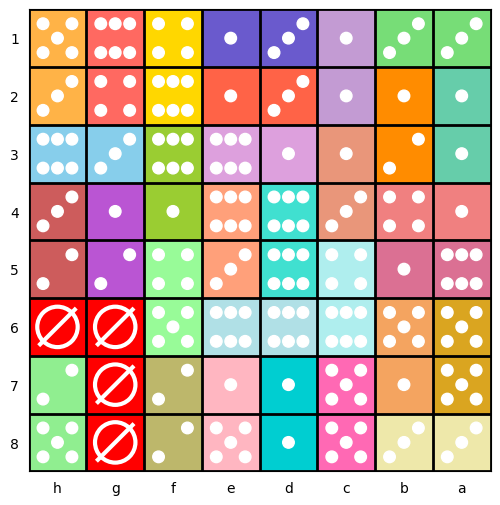

In [37]:
cells = convert_edge_to_cell(solution)
cells_to_erase = convert_node_to_cell(nodes_to_remove)

plot_chessboard(
                erased_cells=cells_to_erase,
                domino_cells = cells
                )

# Tiling Massimale (Non mostrare)

In [21]:
def solve_max_domino_tiling(G):
    model = gp.Model('max_domino_tiling')
    model.setParam('OutputFlag', 0)

    # x_{u,v} = 1 se piazziamo un domino sull'arco (u,v)
    x = model.addVars(G.edges(), vtype=GRB.BINARY, name="x")

    # What about the constraints?
    for v in G.nodes():
        elems = []
        for u in G.neighbors(v):
            if (v,u) in x:
                elems.append((v,u))
            if (u,v) in x:
                elems.append((u,v))
        
        if len(elems) > 0:
            model.addConstr(gp.quicksum(x[u,v] for (u, v) in elems) <= 1)

    # Obiettivo: massimizzare il numero di tessere usate
    # model.setObjective(0, GRB.MAXIMIZE) # Dummy objective works ???
    model.setObjective(gp.quicksum(x[e] for e in G.edges()), GRB.MAXIMIZE)

    model.optimize()
    return model, x

In [22]:
# PER RIMUOVERE LE CELLE DELLA SCACCHIERA

nodes_to_remove = [0, 63]
# nodes_to_remove = [0, 1]
# nodes_to_remove = [40, 41, 49, 57]


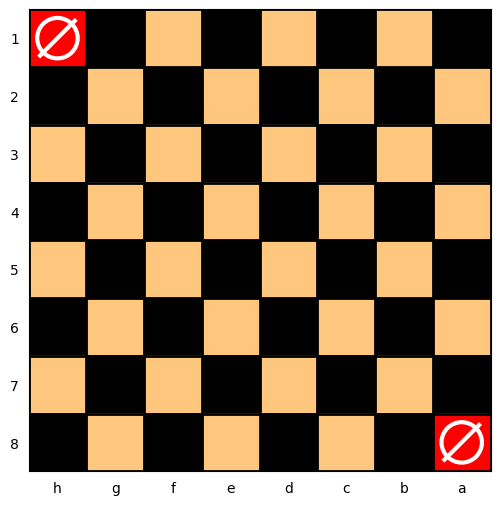

In [30]:
cells_to_erase = convert_node_to_cell(nodes_to_remove)

plot_chessboard(
                erased_cells=cells_to_erase
                )

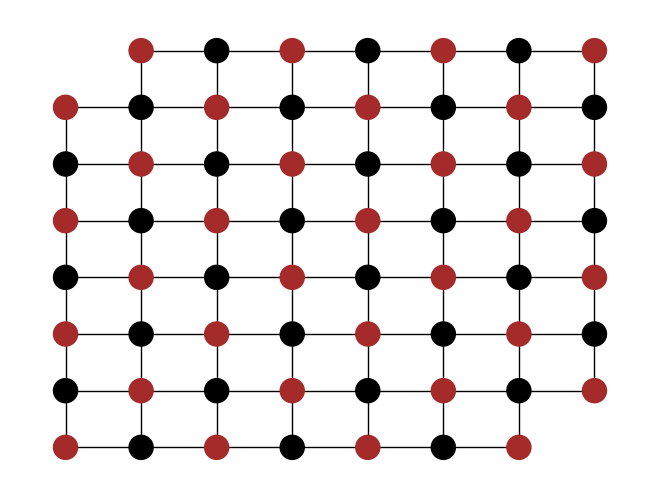

In [27]:
G = plot_graph(nodes, N, nodes_to_remove)

In [28]:
model, x = solve_max_domino_tiling(G)

solution = []

if model.status == GRB.OPTIMAL:
    print("Optimal solution found!")
    for (u,v) in x:
        if x[u,v].X == 1:
            solution.append((u,v))

Optimal solution found!


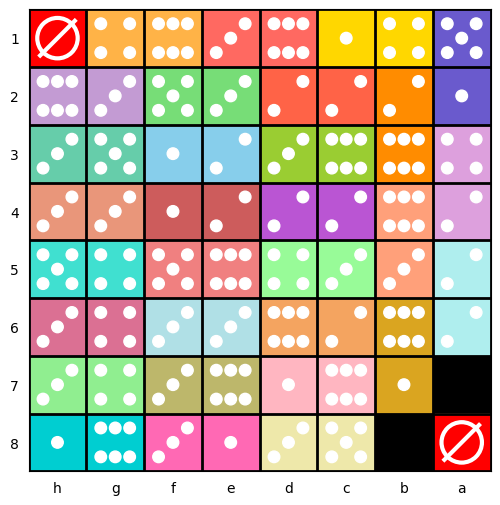

In [29]:
cells = convert_edge_to_cell(solution)
cells_to_erase = convert_node_to_cell(nodes_to_remove)

plot_chessboard(
                erased_cells=cells_to_erase,
                domino_cells = cells
                )